# Pilot points

In [1]:
import pyemu
import flopy
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

In [2]:
# open pp_data file
tmp_d = r'..\models\local2\pest\local2_template'
nam_f = r'..\models\local2\pest\local2_template\local2.nam'
pp_file = r'..\models\local2\pest\local2_template\npfklayer5pp_inst0pp.dat'

In [3]:
# import with no index, whitespace delimited, and with column names
df_pp = pd.read_csv(pp_file, delim_whitespace=True, header=None, names=['name','x','y','f'], index_col=False)
df_pp.head()

C:\Users\tfo46\AppData\Local\Temp\ipykernel_31220\1202342157.py:2: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead
C:\Users\tfo46\AppData\Local\Temp\ipykernel_31220\1202342157.py:2: ParserWarning: Length of header or names does not match length of data. This leads to a loss of data with index_col=False.


,name,x,y,f
0,pp_0000,555.0,1155.0,1
1,pp_0001,655.0,1155.0,1
2,pp_0002,755.0,1155.0,1
3,pp_0003,855.0,1155.0,1
4,pp_0004,955.0,1155.0,1


In [4]:
sim = flopy.mf6.MFSimulation.load(sim_ws=tmp_d, verbosity_level=0) #modflow.Modflow.load(fs.MODEL_NAM,model_ws=working_dir,load_only=[])
gwf= sim.get_model()
ibound=gwf.dis.idomain.get_data()

sr = pyemu.helpers.SpatialReference.from_namfile(
        nam_f,
        delr=gwf.dis.delr.array, delc=gwf.dis.delc.array)

v = pyemu.geostats.ExpVario(contribution=1.0, a=20000, anisotropy=1, bearing=0)
gs = pyemu.geostats.GeoStruct(variograms=v, nugget=0.0)
ok = pyemu.geostats.OrdinaryKrige(gs, df_pp)
var_f = "npfklayer5pp_inst0pp.ref"
df = ok.calc_factors_grid(
    sr,
    var_filename=var_f, 
    minpts_interp=1,
    maxpts_interp=10,
    )

   could not remove start_datetime
starting interp point loop for 18271 points
took 30.369214 seconds


Text(0.5, 1.0, 'Uncertainty Factors')

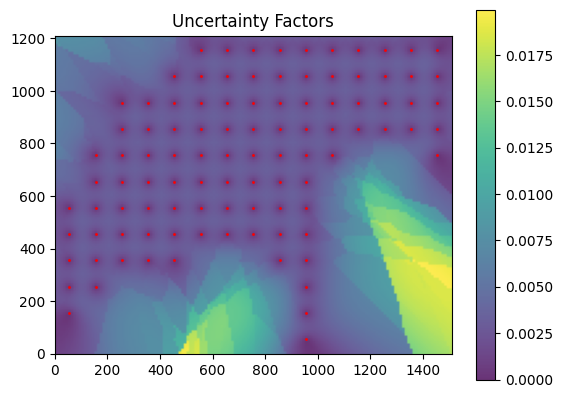

In [5]:
arr_var = np.loadtxt(var_f)
ax = plt.subplot(111,aspect="equal")
p = ax.imshow(arr_var, extent=sr.get_extent(), alpha=0.8)
plt.colorbar(p)
ax.scatter(df_pp.x, df_pp.y, marker='.', s=4, color='r')
ax.set_title('Uncertainty Factors')

We see that there is one row for each model cell, and for each row, we see the distance, names, and weight for the "nearby" pilot points.  The interpolated value for cells that have a pilot point at their center only need one weight - 1.0 - and one pilot point.  Other cells are weighted combinations of pilot points. 

In [6]:
df.head()

,x,y,idist,inames,ifacts,err_var
0,5.0,1205.0,"[353.5533905932738, 430.11626335213134, 430.11626335213134, 474.3416490252569, 474.3416490252569...","[pp_0021, pp_0022, pp_0034, pp_0010, pp_0047, pp_0000]","[0.4215251862520503, 0.02978585595636914, 0.016188937046832032, 0.11511085709091594, 0.259963755...",0.007636
1,15.0,1205.0,"[346.5544690232691, 422.0189569201839, 424.38190347845887, 464.86557196677836, 471.2748667179271...","[pp_0021, pp_0022, pp_0034, pp_0010, pp_0047, pp_0000]","[0.3921129645894399, 0.022151468895445864, 0.01871070962326265, 0.14334740333262697, 0.233636284...",0.007684
2,25.0,1205.0,"[339.70575502926056, 414.004830889689, 418.80783182743846, 455.411901469428, 468.4015371452148, ...","[pp_0021, pp_0022, pp_0034, pp_0010, pp_0047, pp_0000]","[0.39373880818654033, 0.023574886417655514, 0.018243577621401913, 0.14543028292370416, 0.2276980...",0.007673
3,35.0,1205.0,"[333.01651610693426, 406.07881008493905, 413.40053217188773, 445.9820624195552, 465.725240887800...","[pp_0021, pp_0022, pp_0034, pp_0010, pp_0047, pp_0000]","[0.39525141618638326, 0.025084552310752684, 0.017698366369292447, 0.14763097483784263, 0.2216715...",0.007661
4,45.0,1205.0,"[326.49655434629017, 398.24615503479754, 408.16663263917104, 436.5775990588615, 463.249392876018...","[pp_0021, pp_0022, pp_0034, pp_0010, pp_0047, pp_0000]","[0.3966296708686852, 0.026684989540884246, 0.017073281141604363, 0.14995700371355175, 0.21556273...",0.007647


In [7]:
fac_f = pp_file+".fac"
ok.to_grid_factors_file(fac_f)
print(fac_f)

..\models\local2\pest\local2_template\npfklayer5pp_inst0pp.dat.fac


In [8]:
hk_arr = pyemu.geostats.fac2real(pp_file, factors_file=fac_f, out_file=None)

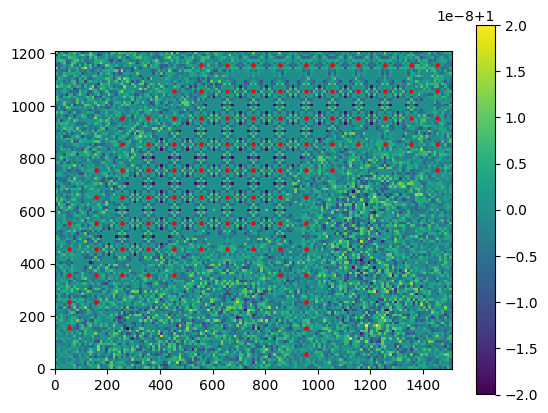

In [9]:
# plot
ax = plt.subplot(111,aspect='equal')
p = ax.imshow(hk_arr, interpolation="nearest", extent=sr.get_extent(),alpha=1)
plt.colorbar(p)
ax.scatter(df_pp.x, df_pp.y, marker='.', s=20, color='red')